In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

In [3]:
df = pd.read_csv("BostonHousing.csv")
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
print("Dataset Preview:")
print(df.head())

Dataset Preview:
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [ ]:
X = df.iloc[:,0:13].values
Y = df.iloc[:,13].values

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=10
)

In [ ]:
print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


Train Shape: (404, 13)
Test Shape: (102, 13)


In [ ]:
sc = StandardScaler()

In [ ]:
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
model = Sequential()
model.add(Dense(100, activation='relu', input_dim=13))
model.add(Dense(30, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])
model.fit(X_train, Y_train, epochs=100, batch_size=10, verbose=0)

In [ ]:
Y_pred_train=model.predict(X_train).flatten()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [ ]:
Y_pred_test = model.predict(X_test).flatten()


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [ ]:
mse_test = mean_squared_error(Y_test,Y_pred_test)
rmse_test= np.sqrt(mse_test)
mae_test = mean_absolute_error(Y_test,Y_pred_test)
r2_test = r2_score(Y_test,Y_pred_test)
print('MSE test:', mse_test)
print('RMSE test:', rmse_test)
print('MAE test:', mae_test)
print('R2 test:', r2_test)

MSE test: 13.465002352495494
RMSE test: 3.6694689469316257
MAE test: 2.6461913501515104
R2 test: 0.835210456881634


In [ ]:
mse_train = mean_squared_error(Y_train, Y_pred_train)
rmse_train= np.sqrt(mse_train)
mae_train = mean_absolute_error(Y_train, Y_pred_train)
r2_train = r2_score(Y_train, Y_pred_train)
print('MSE train:', mse_train)
print('RMSE train:', rmse_train)
print('MAE train:', mae_train)
print('R2 train:', r2_train)

MSE train: 3.6315291558128937
RMSE train: 1.9056571453996896
MAE train: 1.3324010166791407
R2 train: 0.9528132914679541


In [ ]:
# Define threshold
threshold = np.median(Y_train)

# Convert actual values
Y_test_class = (Y_test >= threshold).astype(int)

# Convert predicted values
Y_pred_class = (Y_pred_test >= threshold).astype(int)

In [ ]:
cm = confusion_matrix(Y_test_class, Y_pred_class)

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[17 18]
 [29 38]]


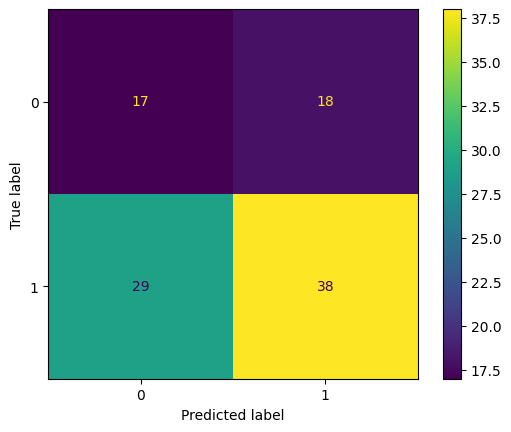

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
# plt.show()